In [23]:
import pandas as pd
import numpy as np
import sys
import gseapy as gp
from typing import Dict, Optional, Tuple, Any, List
import math
import json
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import warnings
from scipy.stats import spearmanr
import seaborn as sns

sys.path.append("/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/")
from SynOmics.processing.metadata import MetaData
dataset_dict = {}
original_data = pd.read_csv("Data/original_data.csv", index_col = 0)
dataset_dict["Origin"] = original_data
seed = 1
syn_datas = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
for i, tool in enumerate(syn_datas):
    syn_df = pd.read_csv(f"Data/{syn_datas[i]}.csv", index_col = 0)
    dataset_dict[tool] = syn_df


mapped_dataset = {}
with open("ssGSEA/mapping_genes.json", "r") as f:
    genes_mapping = json.load(f)
    
abnormal_counts = []
nan_counts = []
for k, v in genes_mapping.items():
    if isinstance(v[0], float) and math.isnan(v[0]):
        nan_counts.append([k, v])
        abnormal_counts.append([k,v])
    elif len(v) > 1 and isinstance(v[0], str):
        abnormal_counts.append([k,v])
        genes_mapping[k]=[v[0]]
            
def ensembl_to_hugo(col, mapping):
    ensembl_id = col.split('.')[0]  # Remove version
    hugo = mapping.get(ensembl_id, [col])  # fallback: leave as is if not found
    return str(hugo[0])
    

for k in nan_counts:
    genes_mapping.pop(k[0], None)

genes_cols = []
for col in original_data.columns:
    if col.startswith("ENSG"):
        genes_cols.append(col)
        
symbols_dataset_dict = {}
for tool, data in dataset_dict.items():
    genes_exp_df = data[genes_cols]
    # Rename column
    genes_exp_df_mapped = genes_exp_df.copy()
    genes_exp_df_mapped.columns = [ensembl_to_hugo(col, genes_mapping) for col in genes_exp_df_mapped.columns]
    
    drop_cols = [col for col in genes_exp_df_mapped.columns if col.startswith("ENSG")]
    genes_exp_df_mapped = genes_exp_df_mapped.drop(columns = drop_cols)
    
    genes_exp_df_mapped_t =genes_exp_df_mapped.T.reset_index()
    genes_exp_df_mapped_t.columns.values[0] = 'Gene'
    
    #Avaraging duplicated genes
    genes_exp_df_mapped_t_grouped = genes_exp_df_mapped_t.groupby("Gene", as_index=False).mean()
    symbols_dataset_dict[tool] = genes_exp_df_mapped_t_grouped

In [24]:
import numpy as np
import pandas as pd
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests
from joblib import Parallel, delayed

def process_dataset(dataname, expression_df, dataset_dict, ph_col, phenotype_A, phenotype_B, eps=1e-9, min_samples=1):
    expr = expression_df.set_index("Gene", drop=False)
    metadata = dataset_dict[dataname]
    mut_samples = metadata[metadata[ph_col] == phenotype_A].index.tolist()
    wt_samples = metadata[metadata[ph_col] == phenotype_B].index.tolist()
    mut_samples = [s for s in mut_samples if s in expr.columns]
    wt_samples = [s for s in wt_samples if s in expr.columns]

    results = []
    for gene in expr.index:
        row = expr.loc[gene]
        mut_vals = pd.to_numeric(row[mut_samples], errors="coerce").dropna().values if mut_samples else np.array([])
        wt_vals = pd.to_numeric(row[wt_samples], errors="coerce").dropna().values if wt_samples else np.array([])

        if mut_vals.size < min_samples or wt_vals.size < min_samples:
            log2fc = np.nan
            p_value = np.nan
        else:
            mut_mean = np.nanmean(mut_vals)
            wt_mean = np.nanmean(wt_vals)

            # Validate means before taking log2: avoid non-finite or non-positive ratios
            if not np.isfinite(mut_mean) or not np.isfinite(wt_mean):
                log2fc = np.nan
            else:
                ratio = (mut_mean + eps) / (wt_mean + eps)
                if not np.isfinite(ratio) or ratio <= 0:
                    log2fc = np.nan
                else:
                    # suppress possible divide/invalid warnings for this explicit check
                    with np.errstate(divide='ignore', invalid='ignore'):
                        log2fc = np.log2(ratio)

            try:
                _, p_value = ranksums(mut_vals, wt_vals, alternative="two-sided")
            except Exception:
                p_value = np.nan

        results.append((gene,
                        float(log2fc) if np.isfinite(log2fc) else np.nan,
                        float(p_value) if np.isfinite(p_value) else np.nan))

    res_df = pd.DataFrame(results, columns=["gene", "log2FC", "pvalue"])
    res_df["padj"] = multipletests(res_df["pvalue"].fillna(1.0), method="fdr_bh")[1]
    res_df["Rank_Score"] = np.sign(res_df["log2FC"]) * (-np.log10(res_df["padj"].clip(lower=1e-300)))
    res_df["Dataset"] = dataname
    return res_df[["gene", "log2FC", "pvalue", "padj", "Rank_Score", "Dataset"]]

def compute_DEGs_parallel(symbols_dataset_dict, dataset_dict, phenotype, n_jobs=-1, backend="loky", min_samples=1):
    ph_col, ph_vals = next(iter(phenotype.items()))
    phenotype_A, phenotype_B = ph_vals[0], ph_vals[1]
    items = list(symbols_dataset_dict.items())

    results = Parallel(n_jobs=n_jobs, backend=backend)(
        delayed(process_dataset)(
            dataname, expression_df, dataset_dict, ph_col, phenotype_A, phenotype_B, 1e-9, min_samples
        )
        for dataname, expression_df in items
    )

    return {dataname: df for (dataname, _), df in zip(items, results)}

In [25]:
phenotype = {"PBRM1": ["MUT","WT"]}
DEGs_paralel = compute_DEGs_parallel(symbols_dataset_dict, dataset_dict, phenotype, n_jobs=-1)

In [26]:
for dataname, df in DEGs_paralel.items():
    df.to_csv(f"DEG/DEG_{dataname}.csv", index = False)

In [27]:
from collections import Iterable
def _to_set(pathways: Iterable[Any], case_sensitive: bool = False) -> set:
    if pathways is None:
        return set()
    if not case_sensitive:
        return {str(x).strip().lower() for x in pathways if pd.notna(x)}
    else:
        return {str(x).strip() for x in pathways if pd.notna(x)}


def compute_jaccard_indices(
    original_pathways: Iterable[Any],
    synth_pathways_dict: Dict[str, Iterable[Any]],
    case_sensitive: bool = False,
) -> pd.DataFrame:
    """
    The Jaccard index is defined as:
        J(A, B) = |A ∩ B| / |A ∪ B|
    """
    if not isinstance(synth_pathways_dict, dict):
        raise ValueError("synth_pathways_dict must be a dict mapping dataset name -> iterable of pathways")

    A = _to_set(original_pathways, case_sensitive=case_sensitive)
    rows = []
    for ds_name, synth_paths in synth_pathways_dict.items():
        B = _to_set(synth_paths, case_sensitive=case_sensitive)
        inter = A.intersection(B)
        union = A.union(B)
        inter_size = len(inter)
        union_size = len(union)

        if union_size == 0:
            # both sets empty -> identical
            j = 1.0
        else:
            j = inter_size / union_size

        rows.append(
            {
                "Dataset": ds_name,
                "Original_count": len(A),
                "Synthetic_count": len(B),
                "Intersection": inter_size,
                "Union": union_size,
                "Jaccard": j,
            }
        )

    df = pd.DataFrame(rows, columns=["Dataset", "Original_count", "Synthetic_count", "Intersection", "Union", "Jaccard"])
    return df


def extract_significant_genes(
    df: pd.DataFrame,
    gene_col: str = "Gene",
    adj_p_col: str = "padj",
    threshold: float = 0.05,
) -> List[str]:
    if df is None or df.empty:
        return []
    if gene_col not in df.columns or adj_p_col not in df.columns:
        return []
    sub = df[df[adj_p_col].astype(float) < float(threshold)].copy()
    # drop NA/empty terms and return list
    sub = sub[sub[gene_col].notna()]
    return [str(x).strip() for x in sub[gene_col].tolist()]

In [28]:
orig_genes = extract_significant_genes(DEGs_paralel["Origin"], gene_col="gene", adj_p_col="padj", threshold=0.25)
synth_genes_dict = {k: extract_significant_genes(v, gene_col="gene", adj_p_col="padj", threshold=0.25)
                     for k, v in DEGs_paralel.items() if k != "Origin"}
jaccard_df = compute_jaccard_indices(orig_genes, synth_genes_dict)
jaccard_df.to_csv(f"DEG/JaccardIndex_{seed}.csv", index = False)

In [29]:
DEG_list = []
for name, df in DEGs_paralel.items():
    DEG_list.append(df)
ssGSEAall_df = pd.concat(DEG_list, axis = 0)
pivot_df = ssGSEAall_df.pivot_table(
    index="gene",
    columns="Dataset",
    values="Rank_Score"
)
if "tvae_42" not in pivot_df.columns.tolist():
    pivot_df["tvae_42"] = np.nan

origin_values = pivot_df["Origin"]

results = []

for dataset in pivot_df.columns:
    if dataset == "Origin":
        continue  # skip comparison with itself
    
    x = origin_values
    y = pivot_df[dataset]

    # Drop rows where either side is NaN
    valid = ~(x.isna() | y.isna())
    rho, pval = spearmanr(x[valid], y[valid])

    results.append({
        "Dataset": dataset,
        "Spearman_rho": rho,
        "p_value": pval,
        "n_terms_used": valid.sum()
    })

# Convert results to DataFrame
spearman_df = pd.DataFrame(results)
spearman_df.to_csv(f"DEG/Spearman_df{seed}.csv", index = False)

In [30]:
# -*- coding: utf-8 -*-
def plot_jaccard_vs_spearman(
    jaccard_df: pd.DataFrame,
    spearman_df: pd.DataFrame,
    dataset_col: str = "Dataset",
    jaccard_col: str = "Jaccard",
    spearman_col: str = "Spearman_rho",
    size_col: Optional[str] = "Synthetic_count",
    annotate: bool = True,
    figsize: Tuple[float, float] = (8, 6),
    savepath: Optional[str] = None,
    title: Optional[str] = "Jaccard index vs Spearman rho",
) -> Tuple[plt.Figure, plt.Axes]:
    # Validate inputs
    if dataset_col not in jaccard_df.columns:
        raise ValueError(f"{dataset_col} not found in jaccard_df")
    if dataset_col not in spearman_df.columns:
        raise ValueError(f"{dataset_col} not found in spearman_df")
    if jaccard_col not in jaccard_df.columns:
        raise ValueError(f"{jaccard_col} not found in jaccard_df")
    if spearman_col not in spearman_df.columns:
        raise ValueError(f"{spearman_col} not found in spearman_df")

    # Merge on dataset
    df = pd.merge(
        spearman_df,
        jaccard_df,
        on=dataset_col,
        how="outer",
        suffixes=("_spearman", "_jaccard"),
    )

    # Prepare columns
    df = df.rename(columns={jaccard_col: "Jaccard", spearman_col: "Spearman_rho"})
    # If user requested size_col but it has different name in jaccard_df, try to keep as-is
    if size_col is not None and size_col not in df.columns:
        # fall back to n_terms_used or Synthetic_count if available
        if "n_terms_used" in df.columns:
            size_col = "n_terms_used"
        elif "Synthetic_count" in df.columns:
            size_col = "Synthetic_count"
        else:
            size_col = None

    # Drop rows that do not have both metrics (can't plot)
    plot_df = df.loc[df["Jaccard"].notna() & df["Spearman_rho"].notna()].copy()

    # If no rows to plot, create empty figure with message
    if plot_df.shape[0] == 0:
        fig, ax = plt.subplots(figsize=figsize)
        ax.text(0.5, 0.5, "No datasets with both Jaccard and Spearman available", ha="center", va="center")
        ax.axis("off")
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        return fig, ax

    # # Compute Spearman correlation between Jaccard and Spearman_rho (on available rows)
    # rho, pval = spearmanr(plot_df["Jaccard"], plot_df["Spearman_rho"], nan_policy="omit")

    # Determine point sizes
    if size_col is not None:
        # scale sizes to a reasonable range
        raw_sizes = plot_df[size_col].fillna(0).astype(float)
        # map zero -> small, others scaled
        min_size = 50
        max_size = 450
        if raw_sizes.max() == raw_sizes.min():
            sizes = np.full(len(raw_sizes), (min_size + max_size) / 2.0)
        else:
            sizes = min_size + (raw_sizes - raw_sizes.min()) / (raw_sizes.max() - raw_sizes.min()) * (max_size - min_size)
    else:
        sizes = 120

    # Create plot
    sns.set(style="whitegrid")
    fig, ax = plt.subplots(figsize=figsize)

    scatter = ax.scatter(
        x=plot_df["Jaccard"],
        y=plot_df["Spearman_rho"],
        s=sizes,
        c="tab:blue",
        edgecolor="k",
        alpha=0.85,
        linewidth=0.6,
        zorder=3,
    )


    # Annotate each point with dataset name if requested (with small offset)
    if annotate:
        for _, row in plot_df.iterrows():
            dx = 0.005 * (ax.get_xlim()[1] - ax.get_xlim()[0])  # small fraction of x-range
            dy = 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])  # small fraction of y-range
            ax.text(
                row["Jaccard"] + dx,
                row["Spearman_rho"] + dy,
                str(row[dataset_col]),
                fontsize=8,
                verticalalignment="bottom",
                horizontalalignment="left",
            )

    # Labels, title, legend, annotation for correlation
    ax.set_xlabel("Jaccard index", fontsize=11)
    ax.set_ylabel("Spearman rho", fontsize=11)
    ax.set_title(title, fontsize=12)



    # A grid and tight layout
    ax.grid(alpha=0.4, linestyle="--")
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    return fig, ax

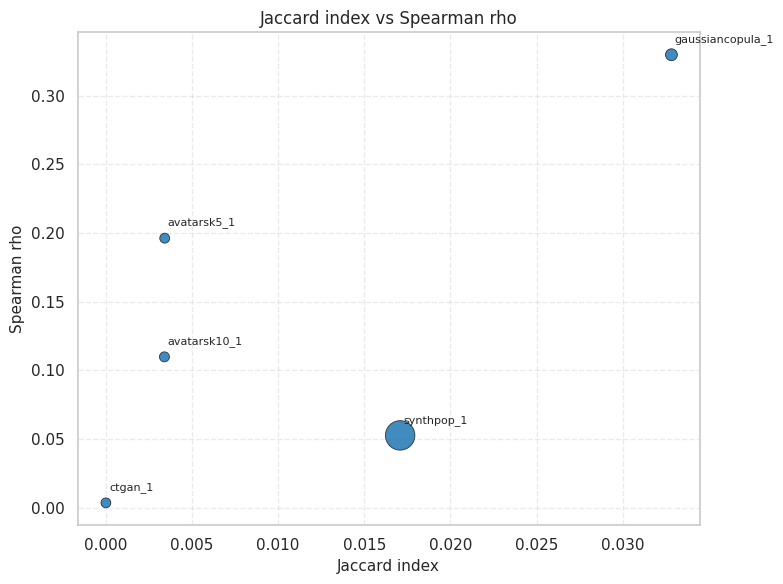

In [31]:
fig, ax = plot_jaccard_vs_spearman(jaccard_df, spearman_df, 
                                   size_col="Synthetic_count", annotate=True, savepath=f"DEG/JaccardIndex_Spearman_{seed}.png")
plt.show()

In [32]:
import matplotlib.pyplot as plt
from typing import Mapping, Sequence, Optional, Tuple, Dict, List

def plot_log2fc_compare(
    genes: Sequence[str],
    datasets: Mapping[str, Sequence[float]],
    threshold: float = 1.0,
    mode: str = "grid",
    ncols: int = 3,
    sharey: bool = True,
    sort: Optional[str] = None,
    annotate: bool = False,
    figsize: Optional[Tuple[float, float]] = None,
    jitter: float = 0.15,
    colors: Optional[Mapping[str, str]] = None,
    markers: Optional[Sequence[str]] = None,
    alpha: float = 0.9,
    marker_size: int = 50,
    show_xticklabels: str = "bottom_only",  # 'all' | 'bottom_only' | 'none'
    label_step: int = 2,                    # show every Nth gene label for readability
    xtick_fontsize: int = 10,
    xtick_rotation: int = 60,               # 45–90 helps readability
    panel_title_size: int = 13,
    suptitle_size: int = 18,
    suptitle_y: float = 0.99,
    title: Optional[str] = None,
    save_path: Optional[str] = None,
    # new options to handle large gene sets and legend control
    max_xtick_genes: int = 100,             # if number of genes > this, hide gene labels and legends
    show_regulation_legend: Optional[bool] = None,
):
    """
    Create comparative scatter plots of genes vs. Log2FC across multiple datasets.

    Notes on changes:
    - If the number of genes exceeds `max_xtick_genes`, gene x-labels and per-panel legends
      are suppressed for readability.
    - You can override legend behavior with show_regulation_legend (True/False). Default is
      to hide legend when N > max_xtick_genes.
    """
    genes = list(genes)
    if threshold < 0:
        raise ValueError("threshold must be non-negative.")
    if not datasets or len(datasets) < 2:
        raise ValueError("Provide at least two datasets to compare.")
    if label_step < 1:
        label_step = 1

    ds_names = list(datasets.keys())
    Y = []
    for name in ds_names:
        arr = np.asarray(datasets[name], dtype=float)
        if arr.shape[0] != len(genes):
            raise ValueError(f"Dataset '{name}' length ({arr.shape[0]}) != number of genes ({len(genes)}).")
        Y.append(arr)
    Y = np.vstack(Y)  # (K, N)
    K, N = Y.shape
    x = np.arange(N)

    # If too many genes, force hide xticks/annotations/legends for readability
    large_gene_set = N > max_xtick_genes
    if large_gene_set:
        # hide xticklabels regardless of user preference
        show_xticklabels_effective = "none"
        # default: hide regulation legend when large set; allow override if user specified explicitly
        if show_regulation_legend is None:
            show_regulation_legend_effective = False
        else:
            show_regulation_legend_effective = bool(show_regulation_legend)
        annotate_effective = False
    else:
        show_xticklabels_effective = show_xticklabels
        show_regulation_legend_effective = True if show_regulation_legend is None else bool(show_regulation_legend)
        annotate_effective = annotate

    # Determine sort order
    if sort is None:
        order = np.arange(N)
    elif sort == "mean":
        order = np.argsort(Y.mean(axis=0))
    else:
        if sort not in ds_names:
            raise ValueError(f"sort must be None, 'mean', or one of {ds_names}.")
        order = np.argsort(Y[ds_names.index(sort)])
    genes = [genes[i] for i in order]
    Y = Y[:, order]
    x = np.arange(N)

    # Colors and markers
    if colors is None:
        palette = plt.get_cmap("tab10")
        colors_map = {name: palette(i % 10) for i, name in enumerate(ds_names)}
    else:
        colors_map = {name: colors.get(name, plt.get_cmap("tab10")(i % 10)) for i, name in enumerate(ds_names)}
    markers_cycle = (markers if markers is not None else ["o", "s", "^", "D", "v", "P", "X", "*"])

    # Y limits with padding
    y_min = float(np.nanmin(Y))
    y_max = float(np.nanmax(Y))
    pad = 0.1 * max(1.0, y_max - y_min)
    y_lo = min(y_min, -threshold) - pad
    y_hi = max(y_max, threshold) + pad

    # Figure size defaults tuned for readability
    if figsize is None:
        if mode == "grid":
            nrows = int(np.ceil(K / ncols))
            per_col_w = max(4.5, 0.10 * (N / max(1, label_step)) + 3.5)
            figsize = (min(28, per_col_w * ncols), min(18, 3.8 * nrows + 2.0))
        else:
            figsize = (min(32, max(12, 0.14 * (N / max(1, label_step)) + 10)), 8.5)

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    try:
        fig.set_constrained_layout_pads(h_pad=0.03, w_pad=0.03, hspace=0.05, wspace=0.05)
    except Exception:
        pass

    axes: List[plt.Axes] = []

    def _apply_common(ax, show_xticks: bool):
        ax.axhline(threshold, color="black", linestyle="--", linewidth=1.3, alpha=0.85, zorder=0)
        ax.axhline(-threshold, color="black", linestyle="--", linewidth=1.3, alpha=0.85, zorder=0)
        ax.axhline(0, color="black", linestyle=":", linewidth=1.0, alpha=0.6, zorder=0)
        ax.set_ylim(y_lo, y_hi)
        ax.grid(True, axis="y", linestyle="--", alpha=0.25)
        if show_xticks:
            ticks = x[::label_step]
            ax.set_xticks(ticks)
            labels = [genes[i] for i in ticks]
            ha = "right" if 0 < xtick_rotation < 90 else ("center" if xtick_rotation == 90 else "center")
            ax.set_xticklabels(labels, rotation=xtick_rotation, fontsize=xtick_fontsize, ha=ha)
        else:
            ax.set_xticks([])
            ax.set_xticklabels([])

    if mode == "grid":
        nrows = int(np.ceil(K / ncols))
        gs = fig.add_gridspec(nrows, ncols)
        for i, name in enumerate(ds_names):
            r, c = divmod(i, ncols)
            ax = fig.add_subplot(gs[r, c], sharey=(axes[0] if (sharey and axes) else None))
            y = Y[i]

            up_mask = y >= threshold
            down_mask = y <= -threshold
            mid_mask = ~(up_mask | down_mask)

            ax.scatter(x[mid_mask], y[mid_mask], c="#B0B0B0", s=marker_size, alpha=alpha, label="Within ±thr")
            ax.scatter(x[up_mask], y[up_mask], c="#E45756", s=marker_size, alpha=alpha, label="Up (≥ +thr)")
            ax.scatter(x[down_mask], y[down_mask], c="#4C78A8", s=marker_size, alpha=alpha, label="Down (≤ -thr)")

            show_ticks = (show_xticklabels_effective == "all") or (show_xticklabels_effective == "bottom_only" and r == nrows - 1)
            _apply_common(ax, show_ticks)

            ax.set_title(name, fontsize=panel_title_size, pad=6)
            if r == nrows - 1:
                ax.set_xlabel("Genes")
            if c == 0:
                ax.set_ylabel("Log2 Fold Change (Log2FC)")

            if annotate_effective and (up_mask.any() or down_mask.any()):
                for j in np.where(up_mask | down_mask)[0]:
                    ax.annotate(
                        genes[j],
                        (x[j], y[j]),
                        textcoords="offset points",
                        xytext=(0, 6),
                        ha="center",
                        fontsize=max(7, xtick_fontsize - 2),
                        rotation=90,
                        clip_on=True,
                    )

            axes.append(ax)

        # Legend handling: only show legend if user allows and set to True
        if show_regulation_legend_effective and axes:
            handles, labels = axes[0].get_legend_handles_labels()
            if handles:
                w, h = fig.get_size_inches()
                fig.set_size_inches(w + 2.0, h, forward=True)
                lg = fig.legend(
                    handles, labels,
                    loc="center left",
                    bbox_to_anchor=(1.02, 0.5),
                    ncol=1,
                    frameon=False,
                    fontsize=14,
                    markerscale=1.6,
                    handlelength=1.2,
                    handletextpad=0.6,
                    labelspacing=0.6,
                    borderaxespad=0.0,
                    title="Regulation",
                )
                if lg.get_title():
                    lg.get_title().set_fontsize(14)

    elif mode == "overlay":
        ax = fig.add_subplot(111)
        for i, name in enumerate(ds_names):
            y = Y[i]
            dx = (i - (K - 1) / 2.0) * jitter
            ax.scatter(
                x + dx,
                y,
                c=[colors_map[name]],
                s=marker_size,
                alpha=alpha,
                marker=markers_cycle[i % len(markers_cycle)],
                label=name,
                edgecolor="white",
                linewidth=0.5,
            )

        _apply_common(ax, show_xticklabels_effective != "none")
        ax.set_xlabel("Genes")
        ax.set_ylabel("Log2 Fold Change (Log2FC)", fontsize=30)

        # Only show legend if allowed by user and not a huge gene set
        if show_regulation_legend_effective:
            w, h = fig.get_size_inches()
            fig.set_size_inches(w + 2.0, h, forward=True)
            lg = ax.legend(
                loc="center left",
                bbox_to_anchor=(1.02, 0.5),
                ncol=1,
                frameon=False,
                fontsize=14,
                markerscale=1.6,
                title="Dataset",
                handlelength=1.2,
                handletextpad=0.6,
                labelspacing=0.6,
                borderaxespad=0.0,
            )
            if lg.get_title():
                lg.get_title().set_fontsize(14)

        axes = [ax]
    else:
        raise ValueError("mode must be either 'grid' or 'overlay'.")

    if title:
        fig.suptitle(title, y=suptitle_y, fontsize=suptitle_size)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, axes

Detected significant DEGs in Origin = 93


/tmp/ipykernel_923366/1367399808.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(tools, rotation=45, ha="right")


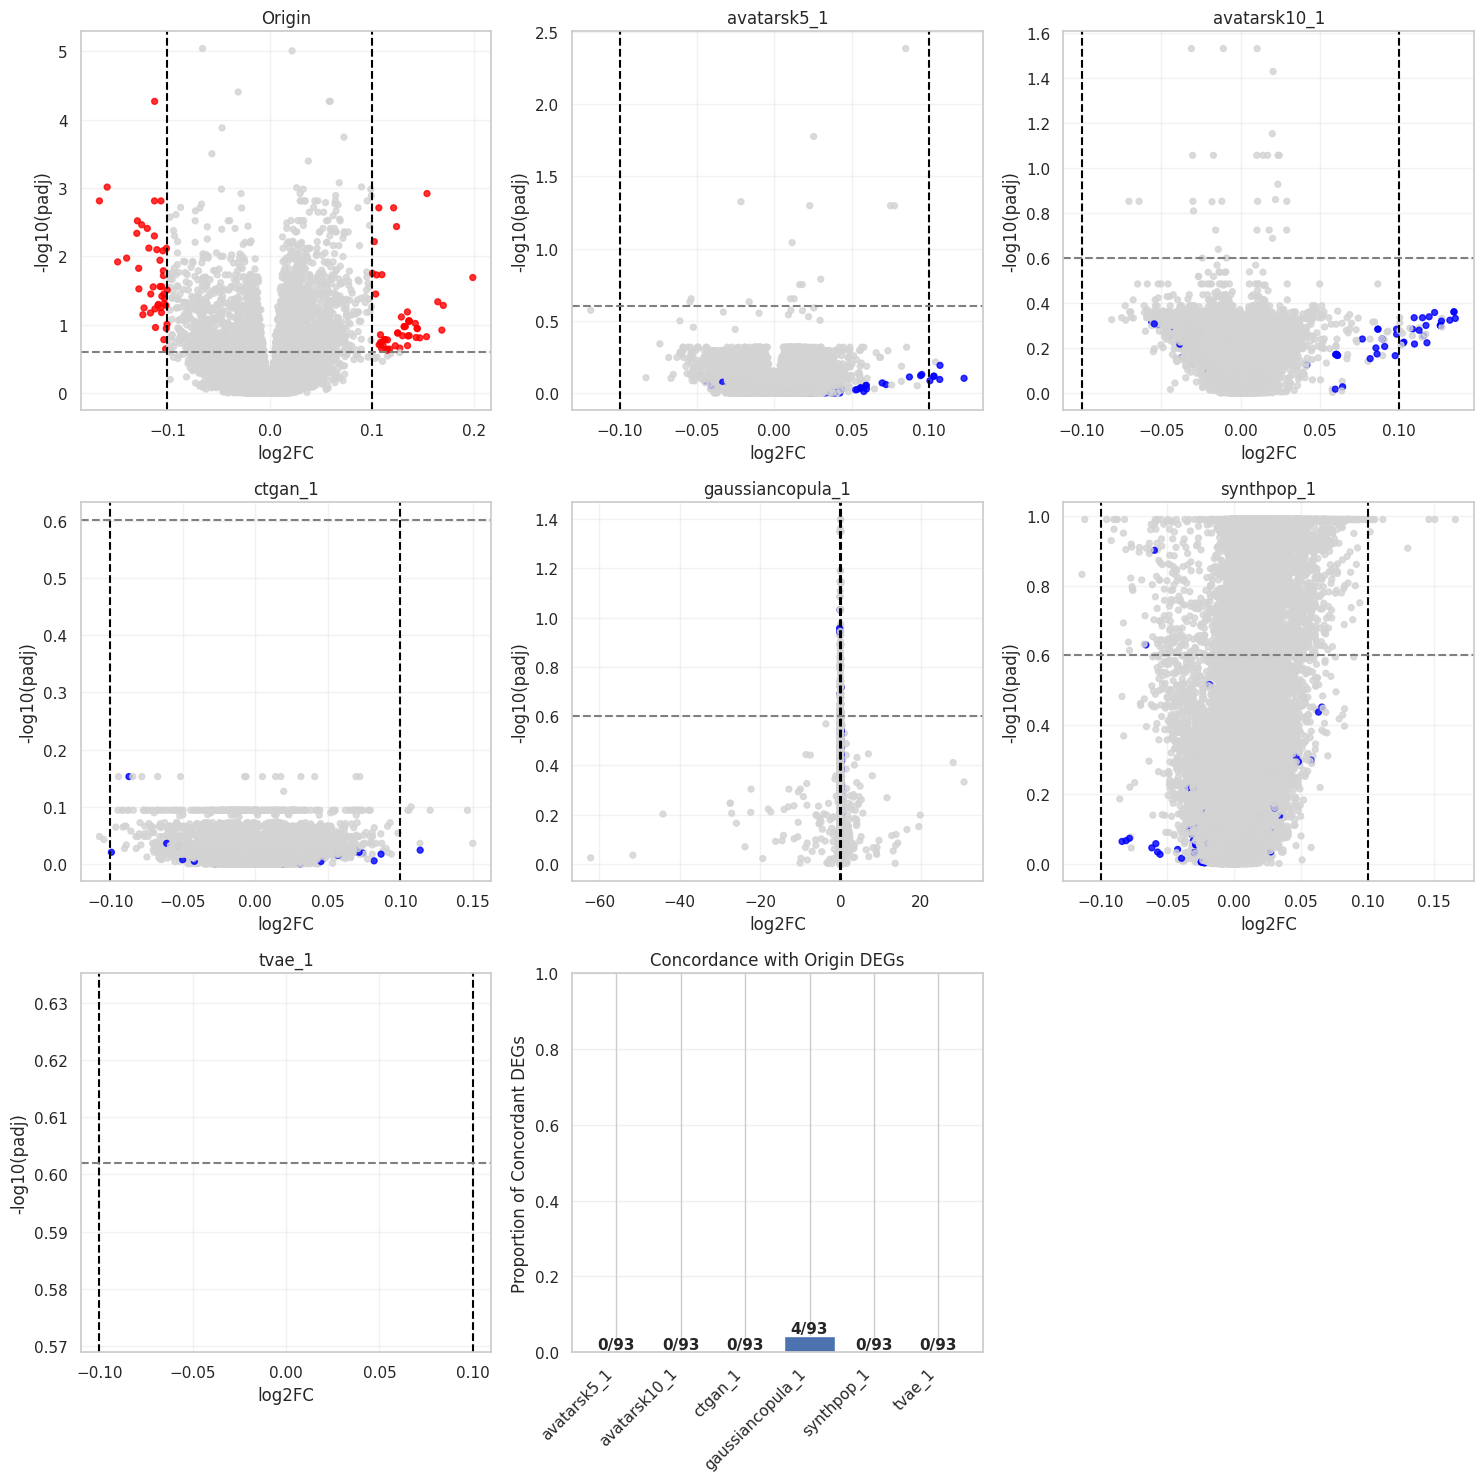

In [33]:
def plot_grid_volcano_with_concordance(
    deg_dict,
    gene_col="gene",
    logfc_col="log2FC",
    pval_col="padj",
    logfc_thresh=1,
    p_thresh=0.05,
    ncols=3,
    figsize_per_plot=5
):

    # ---------------------------------------------
    # 1. Determine significant DEGs in Origin
    # ---------------------------------------------
    origin_df = deg_dict["Origin"]

    sig_origin = set(
        origin_df.loc[
            (origin_df[pval_col] < p_thresh) &
            (origin_df[logfc_col].abs() > logfc_thresh),
            gene_col
        ]
    )

    n_origin = len(sig_origin)
    print(f"Detected significant DEGs in Origin = {n_origin}")

    # ---------------------------------------------
    # 2. Compute concordance for each dataset
    # ---------------------------------------------
    concordance_counts = {}

    for tool, df in deg_dict.items():
        if tool == "Origin":
            continue

        filtered = df[df[gene_col].isin(sig_origin)]
        count = len(filtered.loc[
            (filtered[pval_col] < p_thresh) &
            (filtered[logfc_col].abs() > logfc_thresh),
            gene_col
        ])
        concordance_counts[tool] = count

    # Convert to proportions
    concordance_prop = {k: v / n_origin for k, v in concordance_counts.items()}

    # ---------------------------------------------
    # 3. Setup grid (extra subplot for barplot)
    # ---------------------------------------------
    keys = list(deg_dict.keys())
    n_plots = len(keys) + 1      # volcano plots + barplot
    nrows = int(np.ceil(n_plots / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_plot * ncols, figsize_per_plot * nrows)
    )
    axes = axes.flatten()

    # ---------------------------------------------
    # 4. Draw volcano plots
    # ---------------------------------------------
    for i, name in enumerate(keys):
        ax = axes[i]
        df = deg_dict[name]

        x = df[logfc_col]
        y = -np.log10(df[pval_col])

        # Origin: color by its own significance
        if name == "Origin":
            colors = df.apply(
                lambda row: "red" if (
                    row[pval_col] < p_thresh and abs(row[logfc_col]) > logfc_thresh
                ) else "lightgray",
                axis=1
            )
        else:
            colors = df[gene_col].apply(
                lambda g: "blue" if g in sig_origin else "lightgray"
            )

        ax.scatter(x, y, c=colors, s=18, alpha=0.8)

        ax.axvline(logfc_thresh, linestyle="--", color="black")
        ax.axvline(-logfc_thresh, linestyle="--", color="black")
        ax.axhline(-np.log10(p_thresh), linestyle="--", color="gray")

        ax.set_title(name)
        ax.set_xlabel(logfc_col)
        ax.set_ylabel(f"-log10({pval_col})")
        ax.grid(alpha=0.25)

    # ---------------------------------------------
    # 5. Add final barplot of concordance
    # ---------------------------------------------
    ax_bar = axes[len(keys)]
    tools = list(concordance_prop.keys())
    props = list(concordance_prop.values())
    counts = [concordance_counts[k] for k in tools]

    bars = ax_bar.bar(tools, props)
    ax_bar.set_xticklabels(tools, rotation=45, ha="right")
    
    # Add numbers above bars
    for bar, count in zip(bars, counts):
        ax_bar.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{count}/{n_origin}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    ax_bar.set_title("Concordance with Origin DEGs")
    ax_bar.set_ylabel("Proportion of Concordant DEGs")
    ax_bar.set_ylim(0, 1)
    ax_bar.grid(axis="y", alpha=0.3)

    # ---------------------------------------------
    # 6. Hide unused cells
    # ---------------------------------------------
    for j in range(len(keys) + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
    return fig


fig = plot_grid_volcano_with_concordance(
DEGs_paralel,
    gene_col="gene",
    logfc_col="log2FC",
    pval_col="padj",
    logfc_thresh=0.1,
    p_thresh=0.25,
    ncols=3        
)
fig.savefig(f"DEG/VolcanoPlots_{seed}.png", dpi = 300, bbox_inches="tight")